# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [30]:
# importar librerías
import pandas as pd

# Instacart_orders

In [31]:
# lectura de dataset instacart_orders.csv desde la carpeta datos usando pandas
orders = pd.read_csv('datos/instacart_orders.csv', sep=';')

# Inspección de las primeras filas del dataset
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [32]:
# Información de las características del dataset orders
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [33]:
# Muestreo aleatorio de filas del dataset orders
orders.sample(10)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
271590,3197362,20965,96,6,10,3.0
421031,1801226,67901,4,1,10,13.0
198811,1210659,149204,12,3,8,30.0
304661,2518456,129985,5,1,13,6.0
3708,316839,140568,4,6,11,14.0
307496,2463770,172995,41,3,9,6.0
124811,3043981,132298,77,3,13,2.0
397657,399245,153237,1,4,15,NaN
168422,883415,166597,12,0,14,8.0
437117,496154,31943,10,6,7,15.0


In [34]:
# Estadísticas descriptivas del dataset orders
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789670e+05,478967.000000,478967.000000,478967.000000,478967.000000,450148.000000
mean,1.709947e+06,102966.537475,17.157808,2.775058,13.446676,11.101751
std,9.869480e+05,59525.328991,17.704688,2.045869,4.224986,9.189975
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000
25%,8.564685e+05,51414.000000,5.000000,1.000000,10.000000,4.000000
50%,1.709522e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.562990e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

- Existen 6 columnas en el dataset y 478967 filas.
- Los tipos de datos se ven coherentes, sin embargo, days_since_prior_order se muestra como datos flotantes, a pesar de tener datos numéricos de 0 a 30 sin decimales.
- El dataset dispone de valores faltantes en days_since_prior_order, ya que existen 450148 registro de un total de 478967 filas.
- Considerando la estadística de los datos, se puede observar que el dataset es una muestra, ya que la numeración máxima de la orden es 3 421 079 y el mínimo 4, lo cual no coincide con los más de 400000 registros.

# Products.csv

In [35]:
# lectura de dataset products.csv desde la carpeta datos usando pandas
products = pd.read_csv('datos/products.csv', sep=';')

# Inspección de las primeras filas del dataset
products.head(10)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [36]:
# Información de las características del dataset products
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [37]:
# Muestreo aleatorio de filas del dataset products
products.sample(5)

,product_id,product_name,aisle_id,department_id
48391,48392,Gentleslide Mint Dental Flossers,20,11
45638,45639,Ketchup,72,13
2671,2672,Grande Hard & Soft Taco Shells,30,6
690,691,Organic Promise Strawberry Fields Cereal,121,14
23216,23217,Diet The Original Cream Soda,77,7


In [38]:
# Estadísticas descriptivas del dataset products
products.describe()

,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

- Existen 4 columnas en el dataset y 49694 filas.
- Los tipos de datos son correctos.
- El dataset dispone de valores faltantes en product_name, ya que existen 48436 registros de un total de 49694 filas.
- Considerando la estadística de los datos, se puede observar que existen 21 departamentos y 134 islas, además de 49694 productos. Esto nos indica que existe la población total de productos.

# Aisles.csv

In [39]:
# lectura de dataset aisles.csv desde la carpeta datos usando pandas
aisles = pd.read_csv('datos/aisles.csv', sep=';')

# Inspección de las primeras filas del dataset
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [40]:
# Información de las características del dataset aisles
aisles.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [41]:
# Muestreo aleatorio de filas del dataset aisles
aisles.sample(10)

,aisle_id,aisle
58,59,canned meals beans
54,55,shave needs
122,123,packaged vegetables fruits
102,103,ice cream toppings
94,95,canned meat seafood
128,129,frozen appetizers sides
38,39,seafood counter
48,49,packaged poultry
81,82,baby accessories
92,93,breakfast bakery


In [42]:
# Estadísticas descriptivas del dataset aisles
aisles.describe()

,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

- Existen 2 columnas en el dataset y 134 filas.
- Los tipos de datos son coherentes.
- No existen valores faltantes.
- Considerando la estadística de los datos, se puede observar que existe un orden en la numeración de las islas. 
- Adicionalmente, la numeración y total de filas coincide, por lo que el dataset corresponde al total de los datos, por lo que corresponde a la población. 

# Departments.csv

In [43]:
# lectura de dataset departments.csv desde la carpeta datos usando pandas
departments = pd.read_csv('datos/departments.csv', sep=';')

# Inspección de las primeras filas del dataset
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [44]:
# Información de las características del dataset departments
departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [45]:
# Muestreo aleatorio de filas del dataset departments
departments.sample(5)

,department_id,department
13,14,breakfast
11,12,meat seafood
12,13,pantry
5,6,international
17,18,babies


In [46]:
# Estadísticas descriptivas del dataset departments
departments.describe()

,department_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

- Existen 2 columnas en el dataset y 21 filas.
- Los tipos de datos son coherentes.
- El dataset no dispone de valores faltantes.
- Considerando la estadística de los datos, se puede observar que existen 21 departamentos. Esto nos indica que existe la población total de departamentos.

# Order_products.csv

In [47]:
# lectura de dataset order_products.csv desde la carpeta datos usando pandas
order_products = pd.read_csv('datos/order_products.csv', sep=';')

# Inspección de las primeras filas del dataset
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [48]:
# Información de las características del dataset order_products
order_products.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [49]:
# Muestreo aleatorio de filas del dataset order_products
order_products.sample(10)

,order_id,product_id,add_to_cart_order,reordered
4433520,626236,890,11.0,1
2060859,3270731,37646,2.0,1
4468062,61438,44820,30.0,1
2349566,2971398,41874,20.0,0
1306511,545997,5876,7.0,0
2998196,1602564,21497,10.0,1
777968,1709671,34126,1.0,1
1780849,3237122,34190,2.0,0
859649,738391,38689,11.0,1
1810857,2560262,16797,2.0,1


In [50]:
# Estadísticas descriptivas del dataset order_products
order_products.describe()

,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

- Existen 4 columnas en el dataset y 4545007 filas.
- add_to_cart_order está especificado como float, sin embargo es un orden, por lo que no pueden existir número decimales.
- El dataset dispone de valores faltantes en add_to_cart_order, ya que existen 4544171 registros de un total de 4545007 filas.

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

* Duplicados Instacart_orders 

In [51]:
# Código para encontrar duplicados en la tabla orders
orders.duplicated().sum()

np.int64(15)

In [52]:
# visualizarción de filas duplicadas en la tabla orders
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


In [53]:
# Código para contar registros de order_dow=3 y order_hour_of_day=2 en la tabla orders
orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)].shape[0]

121

In [54]:
# eliminación definitiva de filas duplicadas en la tabla orders
orders.drop_duplicates(inplace=True)

In [55]:
#verificación de duplicados de numero de orden en la tabla orders
orders.duplicated(subset=['order_id']).sum()

np.int64(0)

* Duplicados Products

In [56]:
# búsqueda de duplicados explícitos en la tabla products
orders.duplicated().sum()

np.int64(0)

In [57]:
# Análisis de tricky duplicates en la tabla products
# Mismo products_id pero diferente product_name
products[products['product_id'].duplicated()]

,product_id,product_name,aisle_id,department_id


In [58]:
# verificar nombres duplicados
# cambiar nombres a minúscula para evitar problemas de mayúscula/minúscula
products['product_name'] = products['product_name'].str.lower()

In [59]:
# Con el mismo nombre pero diferente id
products[products.duplicated(subset=['product_name'], keep=False)].sort_values('product_name')

,product_id,product_name,aisle_id,department_id
23339,23340,18-in-1 hemp peppermint pure-castile soap,25,11
31844,31845,18-in-1 hemp peppermint pure-castile soap,25,11
19941,19942,aged balsamic vinegar of modena,19,13
13152,13153,aged balsamic vinegar of modena,19,13
24830,24831,albacore solid white tuna in water,95,15
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [60]:
# Nombres repetidos que no corresponden a NaN
products[products.duplicated(subset=['product_name'], keep=False) & products['product_name'].notna()].sort_values('product_name')

,product_id,product_name,aisle_id,department_id
23339,23340,18-in-1 hemp peppermint pure-castile soap,25,11
31844,31845,18-in-1 hemp peppermint pure-castile soap,25,11
19941,19942,aged balsamic vinegar of modena,19,13
13152,13153,aged balsamic vinegar of modena,19,13
24830,24831,albacore solid white tuna in water,95,15
...,...,...,...,...
46873,46874,vitamin d3 5000 iu,47,11
21366,21367,wild sardines in spring water,95,15
40093,40094,wild sardines in spring water,95,15
1826,1827,yams cut sweet potatoes in syrup,81,15


* Duplicados order_products

In [61]:
# Búsqueda de duplicados explícitos en la tabla order_products
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


* Duplicados Aisles

In [62]:
# Verificación de duplicados en la tabla aisles
aisles[aisles['aisle_id'].duplicated()]

,aisle_id,aisle


In [63]:
# Análisis de tricky duplicates en la tabla aisles
# Mismo aisle_id pero diferente aisle
aisles[aisles.duplicated(subset=['aisle_id'])]

,aisle_id,aisle


In [64]:
# mismo nombre de aisle pero diferente id
# cambio de nombres a minúscula para evitar problemas de mayúscula/minúscula
aisles['aisle'] = aisles['aisle'].str.lower()
aisles[aisles.duplicated(subset=['aisle'])]

,aisle_id,aisle


* Duplicados Departments

In [65]:
# Verificación de duplicados en la tabla departments

departments[departments['department_id'].duplicated()]

,department_id,department


In [66]:
# Análisis de tricky duplicates en la tabla departments
# Mismo department_id pero diferente department
departments[departments.duplicated(subset=['department_id'])]

,department_id,department


In [67]:
# mismo nombre de departments pero diferente id
# cambio de nombres a minúscula para evitar problemas de mayúscula/minúscula
departments['department'] = departments['department'].str.lower()
departments[departments.duplicated(subset=['department'])]

,department_id,department


### Conclusiones sobre la Precisión:
Explica por qué eliminaste (o consolidaste) la información y qué nos enseña sobre la ingesta del sistema.

* Instacart_Orders:
   - Se encontraron duplicados explícitos, correspondientes a 15 filas, las cuales fueron eliminadas. No se encontraron tricky duplicates.

* Products:
   - No se encontraron duplicados explícitos.
   - Existen 207 filas duplicadas en el nombre de producto, sin embargo, se mantendrán, ya que difieren en product_id.
   - Existen más de 1000 productos con nombre faltante que corresponden al departamento 21 e isla 100.
   - La isla 100 tiene nombre faltante al igual que el departamento 21

* Order_products:
   - No se encontraron duplicados explícitos.
   - No se realizó la búsqueda de tricky duplicates, ya que por la naturaleza de la tabla, existirán duplicados en todas las columnas.

* Aisles:
   - No se encontraron duplicados explícitos ni tricky.

* Departments:
   - No se encontraron duplicados explícitos ni tricky.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

Tratamiento de valores ausentes en Tabla Instacart Orders

In [68]:
# Existen valores NAN en las siguientes tablas: orders, products y order_products
# conteo de valores NAN en la tabla orders
#visualización de valores faltantes en la tabla orders
orders[orders.isna().any(axis=1)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [69]:
# valor de order_number para days_since_prior_order con valor NaN
orders[orders['days_since_prior_order'].isna()].order_number.nunique()

1

In [70]:
# Llenar valores NaN en days_since_prior_order con -1 para indicar que no hay un pedido previo
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(-1)

Tratamiento de valores ausentes en Tabla Products

In [71]:
# Verificar nulos en products
products[products.isna().any(axis=1)]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [72]:
#verificar si todos los productos con aisle_id=100 corresponden al mismo product_name
products[products['aisle_id'] == 100]['product_name'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [73]:
# Verificar si todos los productos con department_id=21 corresponden al mismo product_name
products[products['department_id'] == 21]['product_name'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [74]:
# cambio de nombres nan por Desconocido
products['product_name'] = products['product_name'].fillna('Desconocido')

Tratamiento de valores ausentes en Tabla Order_products

In [75]:
# Análisis de valores faltantes en la tabla order_products
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [76]:
# Visualización de filas con valores faltantes en la tabla order_products
order_products[order_products['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [77]:
# Estas son las ordenes que tienen productos sin posicion del carrito de compras
ordenes_faltantes = order_products[order_products['add_to_cart_order'].isna()]['order_id']
ordenes_faltantes.value_counts()

order_id
61355      63
3308010    51
2136777    44
171934     40
1959075    34
           ..
888470      1
2621907     1
2729254     1
9310        1
2170451     1
Name: count, Length: 70, dtype: int64

In [78]:
ordenes_faltantes = ordenes_faltantes.unique()

In [79]:
full_detalle_ordenes_con_posicion_na = order_products[order_products['order_id'].isin(ordenes_faltantes)]
full_detalle_ordenes_con_posicion_na['order_id'].value_counts()

order_id
61355      127
3308010    115
2136777    108
171934     104
1959075     98
          ... 
888470      65
1598369     65
747668      65
1677118     65
2170451     65
Name: count, Length: 70, dtype: int64

In [80]:
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(-1).astype('int')

### Conclusiones sobre la Completitud:
Argumenta qué mecanismo de ausencia (Rubin) encontraste en cada escenario y por qué tus estrategias de imputación no generaron sesgos severos.

* Instacart_Orders:
   - days_since_prior_order presentó valores ausentes del tipo MNAR — Missing Not at Random, ya que los valores ausentes corresponden a la primera compra. Para este caso los valores  fueron llenados con -1 para no afectar a los datos actualemnte en el sistema.

* Products:
   - product_name presentó valores ausentes del tipo MNAR — Missing Not at Random, ya que todos los nombres faltantes corresponden a la isla 100 y departamento 21. En este caso, todos los nombres fueron identificados "Desconocido".

* Order_products:
   -    add_to_cart_order presentó valores ausentes del tipo MNAR — Missing Not at Random, ya que todos los valores faltantes corresponden a compras superiores a 64 items. En este caso, todos los valores fueron reemplazados por -1.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

Tabla Instacart_orders

In [81]:
# Boxplot de days_since_prior_order para verificar usuarios que compran fuer del rango promedio de frecuencia de compra
import matplotlib.pyplot as plt

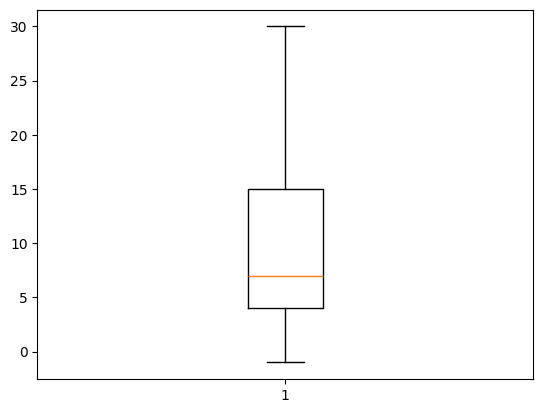

In [83]:
# Boxplot de days_since_prior_order
plt.boxplot(orders['days_since_prior_order'])
plt.show()

In [86]:
# Cálculo de IQR para identificar outliers en days_since_prior_order
Q1 = orders['days_since_prior_order'].quantile(0.25)
Q1

np.float64(4.0)

In [87]:
Q3 = orders['days_since_prior_order'].quantile(0.75)
Q3

np.float64(15.0)

In [88]:
IQR = Q3 - Q1
IQR

np.float64(11.0)

In [89]:
Bigote_inferior = Q1 - 1.5 * IQR
Bigote_inferior

np.float64(-12.5)

In [90]:
Bigote_superior = Q3 + 1.5 * IQR
Bigote_superior

np.float64(31.5)

In [94]:
# Visualizacion de outliers en days_since_prior_order
orders.query(f'days_since_prior_order > {Bigote_superior} or days_since_prior_order < {Bigote_inferior}')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


### Conclusiones sobre la Sensibilidad:
Decide y justifica la estrategia que usaste para estos casos (eliminar, mantener como outlier real o winsorizar).

* Orders: No existen outliers, se mantienen los valores. No existen usuarios que compran fuera de los días, esto también considerando que el rango es de 0 a 30 días, no existen registros de días superiores a 30.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [99]:
# One Big Table para visualizar información de tablas orders_products, products, aisles y departments
# Merge de orders_products con products para obtener información de producto
full_detalle_ordenes = orders.merge(order_products, on='order_id', how='left')
full_detalle_ordenes = full_detalle_ordenes.merge(products, on='product_id', how='left')
full_detalle_ordenes.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,1515936,183418,11,6,13,30.0,19048.0,1.0,1.0,organic butternut squash,83.0,4.0
1,1515936,183418,11,6,13,30.0,47766.0,3.0,1.0,organic avocado,24.0,4.0
2,1515936,183418,11,6,13,30.0,45066.0,9.0,0.0,honeycrisp apple,24.0,4.0
3,1515936,183418,11,6,13,30.0,24082.0,11.0,0.0,organic dark sweet cherries,116.0,1.0
4,1515936,183418,11,6,13,30.0,24363.0,4.0,0.0,lemon cayenne agave cold pressed juice beverage,31.0,7.0


In [100]:
# merge de full_detalle_ordenes con aisles para obtener información de aisle
full_detalle_ordenes = full_detalle_ordenes.merge(aisles, on='aisle_id', how='left')
full_detalle_ordenes.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle
0,1515936,183418,11,6,13,30.0,19048.0,1.0,1.0,organic butternut squash,83.0,4.0,fresh vegetables
1,1515936,183418,11,6,13,30.0,47766.0,3.0,1.0,organic avocado,24.0,4.0,fresh fruits
2,1515936,183418,11,6,13,30.0,45066.0,9.0,0.0,honeycrisp apple,24.0,4.0,fresh fruits
3,1515936,183418,11,6,13,30.0,24082.0,11.0,0.0,organic dark sweet cherries,116.0,1.0,frozen produce
4,1515936,183418,11,6,13,30.0,24363.0,4.0,0.0,lemon cayenne agave cold pressed juice beverage,31.0,7.0,refrigerated


In [101]:
# merge de full_detalle_ordenes con departments para obtener información de department
full_detalle_ordenes = full_detalle_ordenes.merge(departments, on='department_id', how='left')
full_detalle_ordenes.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,1515936,183418,11,6,13,30.0,19048.0,1.0,1.0,organic butternut squash,83.0,4.0,fresh vegetables,produce
1,1515936,183418,11,6,13,30.0,47766.0,3.0,1.0,organic avocado,24.0,4.0,fresh fruits,produce
2,1515936,183418,11,6,13,30.0,45066.0,9.0,0.0,honeycrisp apple,24.0,4.0,fresh fruits,produce
3,1515936,183418,11,6,13,30.0,24082.0,11.0,0.0,organic dark sweet cherries,116.0,1.0,frozen produce,frozen
4,1515936,183418,11,6,13,30.0,24363.0,4.0,0.0,lemon cayenne agave cold pressed juice beverage,31.0,7.0,refrigerated,beverages


In [102]:
full_detalle_ordenes.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle',
       'department'],
      dtype='str')

# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

In [109]:
# Verificar que order_hour_of_day tiene distribuciones lógicas
full_detalle_ordenes['order_hour_of_day'].value_counts().sort_index()

order_hour_of_day
0      31199
1      16668
2       8802
3       7349
4       7577
5      12274
6      39829
7     127310
8     242469
9     345397
10    390924
11    388387
12    367597
13    377631
14    378712
15    375342
16    358902
17    294561
18    229163
19    175816
20    137767
21    113738
22     89891
23     56608
Name: count, dtype: int64

In [110]:
# Verificar que order_dow tiene distribuciones lógicas
full_detalle_ordenes['order_dow'].value_counts().sort_index()

order_dow
0    874124
1    798597
2    595211
3    539410
4    538107
5    592986
6    635478
Name: count, dtype: int64

Gráficas

In [105]:
# librerías para visualización
import seaborn as sns
import numpy as np

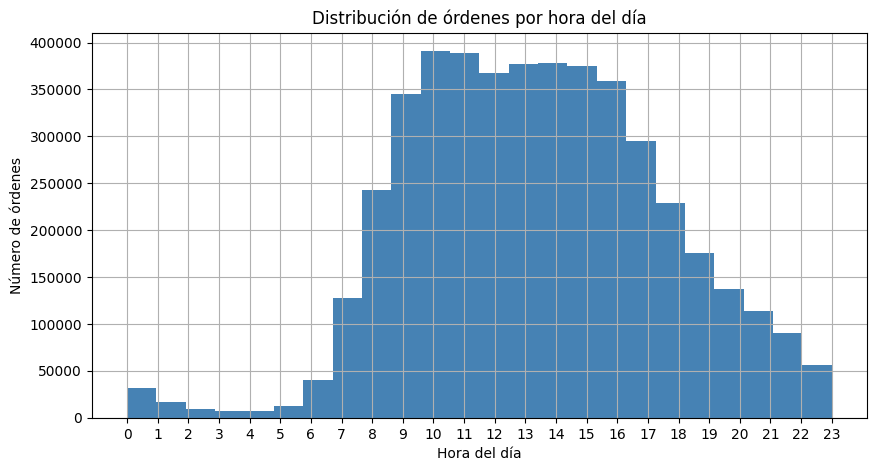

In [112]:
# histogramas para ver qué picos de horas concentran compras
full_detalle_ordenes['order_hour_of_day'].hist(bins=24, figsize=(10, 5), color='steelblue')
plt.title('Distribución de órdenes por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Número de órdenes')
plt.xticks(range(0, 24))
plt.show()

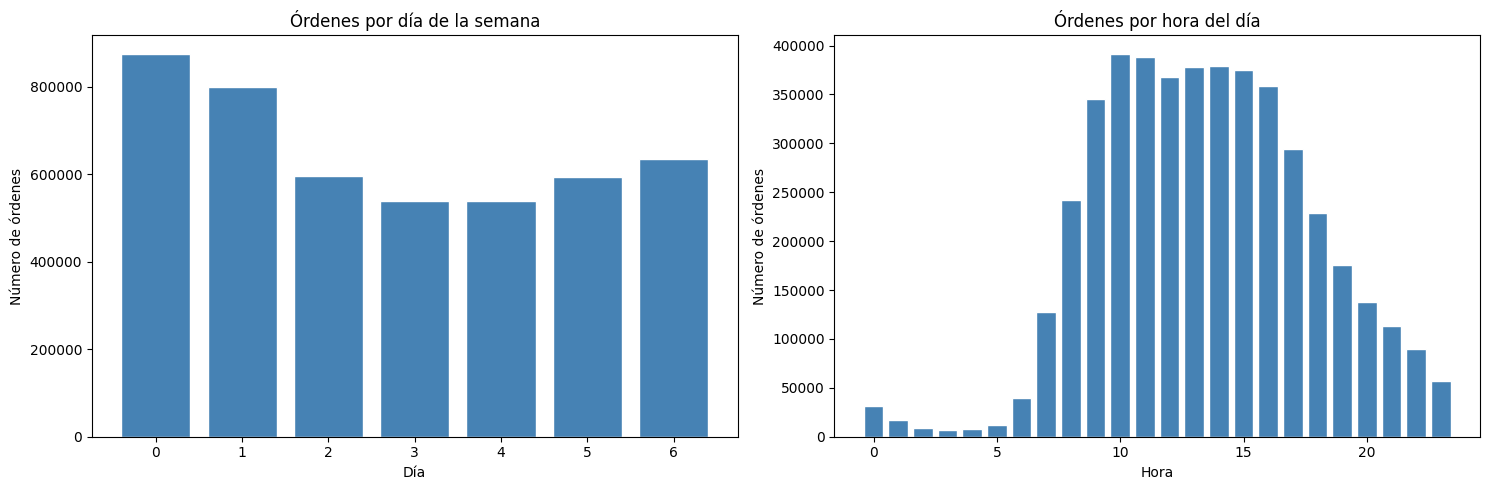

In [113]:
# gráficos de barras para evaluar diferencias de días y horas
conteo_dias = full_detalle_ordenes['order_dow'].value_counts().sort_index()
conteo_horas = full_detalle_ordenes['order_hour_of_day'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Barras por día
ax[0].bar(conteo_dias.index, conteo_dias.values, color='steelblue', edgecolor='white')
ax[0].set_title('Órdenes por día de la semana')
ax[0].set_xlabel('Día')
ax[0].set_ylabel('Número de órdenes')

# Barras por hora
ax[1].bar(conteo_horas.index, conteo_horas.values, color='steelblue', edgecolor='white')
ax[1].set_title('Órdenes por hora del día')
ax[1].set_xlabel('Hora')
ax[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

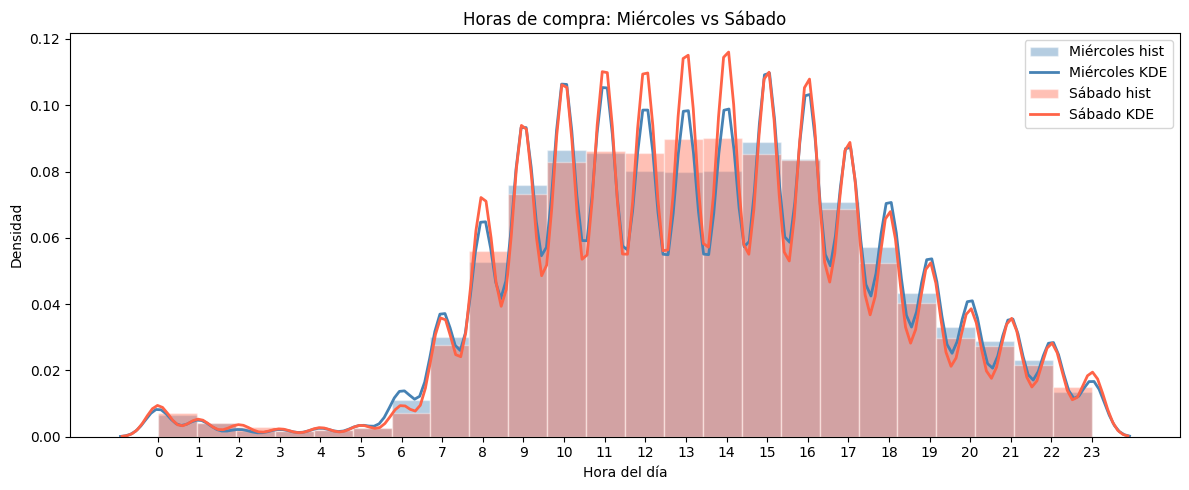

In [122]:
# Gráfica para ver qué picos de horas concentran compras en miércoles y en sábado
mier = df_ordenes[df_ordenes['order_dow'] == 3]['order_hour_of_day']
sab  = df_ordenes[df_ordenes['order_dow'] == 6]['order_hour_of_day']

fig, ax = plt.subplots(figsize=(12, 5))

for serie, label, color in [(mier, 'Miércoles', 'steelblue'), (sab, 'Sábado', 'tomato')]:
    ax.hist(serie, bins=bins_sturges, density=True,
            color=color, edgecolor='white', alpha=0.4, label=f'{label} hist')
    sns.kdeplot(serie, ax=ax, color=color, linewidth=2, label=f'{label} KDE')

ax.set_title('Horas de compra: Miércoles vs Sábado')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Densidad')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()



**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

n = 4,281,985 | bins Sturges = 24
Media:    11.12 días
Mediana:  8.00 días
Moda:     7 días
Skewness: 1.049


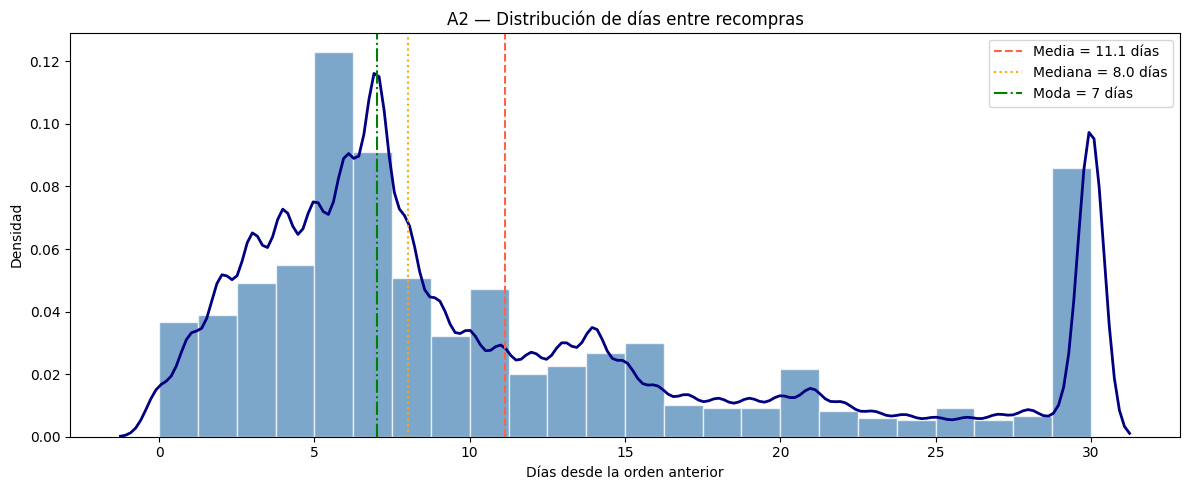

In [123]:
# days_since_prior_order tiene NaN reemplazados con -1 en la primera orden de cada usuario — se los excluirá
recompra = df_ordenes[df_ordenes['days_since_prior_order'] != -1]['days_since_prior_order']

n = len(recompra)
bins_sturges = int(np.ceil(np.log2(n))) + 1
print(f"n = {n:,} | bins Sturges = {bins_sturges}")
print(f"Media:    {recompra.mean():.2f} días")
print(f"Mediana:  {recompra.median():.2f} días")
print(f"Moda:     {recompra.mode()[0]:.0f} días")
print(f"Skewness: {recompra.skew():.3f}")

# Histograma + KDE
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(recompra, bins=bins_sturges, density=True,
        color='steelblue', edgecolor='white', alpha=0.7)
sns.kdeplot(recompra, ax=ax, color='navy', linewidth=2)
ax.axvline(recompra.mean(),   color='tomato', linestyle='--', linewidth=1.5,
           label=f'Media = {recompra.mean():.1f} días')
ax.axvline(recompra.median(), color='orange', linestyle=':',  linewidth=1.5,
           label=f'Mediana = {recompra.median():.1f} días')
ax.axvline(recompra.mode()[0], color='green', linestyle='-.',  linewidth=1.5,
           label=f'Moda = {recompra.mode()[0]:.0f} días')

ax.set_title('A2 — Distribución de días entre recompras')
ax.set_xlabel('Días desde la orden anterior')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

La distribución de días entre recompras presenta asimetría. Existe un primer pico dominante en 7 días, lo que indica que el patrón de recompra más frecuente es semanal, y un segundo pico pronunciado en 30 días, correspondiente a usuarios que recompran mensualmente.

### Tira aquí tus hallazgos estadísticos para el grupo A:
(Debes hablar de cómo se distribuye la demanda, tendencias centrales encontradas y asimetrías de cola).

La demanda horaria sigue una distribución aproximadamente simétrica normal, con actividad baja entre las 0–5h y más compras desde las 6h. 
Existen más compras entre las 10h y las 15h, con el máximo alrededor de las 10h.
Al comparar Miércoles vs. Sábado, ambos días comparten la misma ventana activa (9h–17h), pero el Sábado presenta mayor densidad en ese rango, lo que significa que los usuarios concentran más compras en menos horas durante el fin de semana. 

La distribución de días entre recompras presenta asimetría. Existe un primer pico dominante en 7 días, lo que indica que el patrón de recompra más frecuente es semanal, y un segundo pico pronunciado en 30 días, correspondiente a usuarios que recompran mensualmente.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

In [124]:
# Ordenes por usuario
ordenes_por_usuario = orders.groupby('user_id')['order_id'].nunique()

n usuarios = 157,437 | bins Sturges = 19
Media:    3.04 órdenes
Mediana:  2.00 órdenes
Moda:     1 órdenes
SD:       2.75
Skewness: 2.266
Max:      28 órdenes
Percentil 90: 6 órdenes
Percentil 95: 9 órdenes
Percentil 99: 14 órdenes


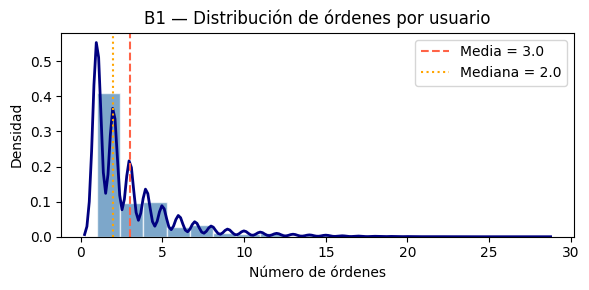

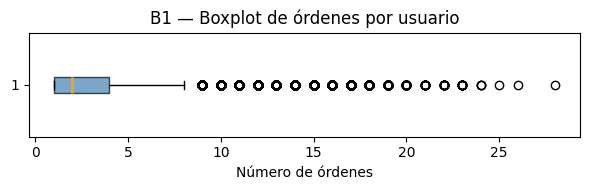

In [128]:
n = len(ordenes_por_usuario)
bins_sturges = int(np.ceil(np.log2(n))) + 1
print(f"n usuarios = {n:,} | bins Sturges = {bins_sturges}")
print(f"Media:    {ordenes_por_usuario.mean():.2f} órdenes")
print(f"Mediana:  {ordenes_por_usuario.median():.2f} órdenes")
print(f"Moda:     {ordenes_por_usuario.mode()[0]:.0f} órdenes")
print(f"SD:       {ordenes_por_usuario.std():.2f}")
print(f"Skewness: {ordenes_por_usuario.skew():.3f}")
print(f"Max:      {ordenes_por_usuario.max()} órdenes")
print(f"Percentil 90: {ordenes_por_usuario.quantile(0.90):.0f} órdenes")
print(f"Percentil 95: {ordenes_por_usuario.quantile(0.95):.0f} órdenes")
print(f"Percentil 99: {ordenes_por_usuario.quantile(0.99):.0f} órdenes")

# Histograma + KDE
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(ordenes_por_usuario, bins=bins_sturges, density=True,
        color='steelblue', edgecolor='white', alpha=0.7)
sns.kdeplot(ordenes_por_usuario, ax=ax, color='navy', linewidth=2)
ax.axvline(ordenes_por_usuario.mean(),   color='tomato', linestyle='--', linewidth=1.5,
           label=f'Media = {ordenes_por_usuario.mean():.1f}')
ax.axvline(ordenes_por_usuario.median(), color='orange', linestyle=':',  linewidth=1.5,
           label=f'Mediana = {ordenes_por_usuario.median():.1f}')

ax.set_title('B1 — Distribución de órdenes por usuario')
ax.set_xlabel('Número de órdenes')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

# Boxplot para visualizar cola y outliers
fig, ax = plt.subplots(figsize=(6, 2))
ax.boxplot(ordenes_por_usuario, vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('B1 — Boxplot de órdenes por usuario')
ax.set_xlabel('Número de órdenes')
plt.tight_layout()
plt.show()

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

In [132]:
# Top 20 de productos más comprados con su ratio de compra
top_productos = full_detalle_ordenes['product_name'].value_counts().head(20)
top_productos_ratio = top_productos / top_productos.sum()
top_productos_ratio

product_name
banana                      0.141527
bag of organic bananas      0.114200
organic strawberries        0.079364
organic baby spinach        0.072790
organic hass avocado        0.063795
organic avocado             0.052902
large lemon                 0.046058
strawberries                0.042893
limes                       0.042190
organic whole milk          0.041997
organic raspberries         0.041134
organic yellow onion        0.034065
organic garlic              0.032766
organic zucchini            0.031249
organic blueberries         0.029739
cucumber kirby              0.029302
organic fuji apple          0.026878
organic lemon               0.026210
apple honeycrisp organic    0.025698
organic grape tomatoes      0.025243
Name: count, dtype: float64

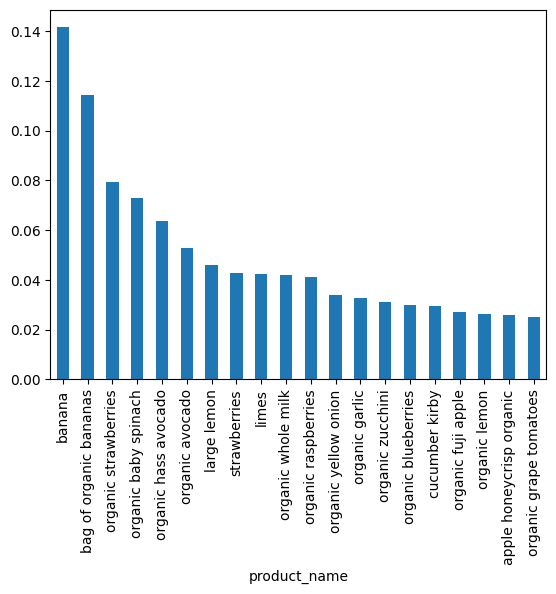

In [133]:
top_productos_ratio.plot(kind='bar', x='product_name', y='num_ordenes')
plt.show()

In [135]:
# Verificar correlación Aisle y volverse recompras
recompra_por_pasillo = (full_detalle_ordenes
    .groupby('aisle')
    .agg(
        total_pedidos = ('order_id', 'count'),
        ratio_recompra = ('reordered', 'mean')
    )
    .sort_values('ratio_recompra', ascending=False)
    .head(15)
    .reset_index()
)

print("\nTop 15 pasillos por ratio de recompra:")
print(recompra_por_pasillo.to_string(index=False))


Top 15 pasillos por ratio de recompra:
                        aisle  total_pedidos  ratio_recompra
                         milk         125522        0.781305
water seltzer sparkling water         117133        0.730605
                 fresh fruits         510101        0.718197
                         eggs          63796        0.706032
              soy lactosefree          89437        0.693091
             packaged produce          39031        0.688248
                       yogurt         203358        0.685918
                        cream          44380        0.685692
                        bread          82082        0.672462
                 refrigerated          80506        0.661826
             breakfast bakery          35004        0.657925
         energy sports drinks          14283        0.654904
                  white wines           4309        0.641216
   packaged vegetables fruits         246918        0.640634
                  soft drinks          50001 

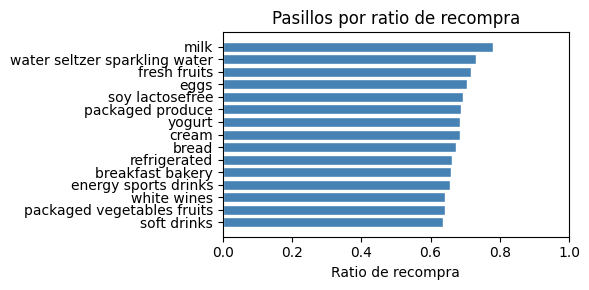

In [138]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(recompra_por_pasillo['aisle'][::-1],
        recompra_por_pasillo['ratio_recompra'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Pasillos por ratio de recompra')
ax.set_xlabel('Ratio de recompra')
ax.set_ylabel('')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### Conclusiones sobre el perfil del carrito [Grupo B]:

El producto más vendido es la banana.
En el análisis de productos de acuerdo a la isla en la que se encuentra, se verifica que el pasillo de milk es el de mayor recompra.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

In [165]:
canasta = full_detalle_ordenes.groupby('order_id')['product_id'].count()
canasta.describe()
print(canasta[canasta == 0].count(), "órdenes con 0 artículos")
canasta = canasta[canasta > 0]  # filtrar y recalcular
print(canasta.describe())
print(f"Kurtosis: {canasta.kurt():.3f}")
print(f"Skewness: {canasta.skew():.3f}")

28906 órdenes con 0 artículos
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64
Kurtosis: 4.127
Skewness: 1.562


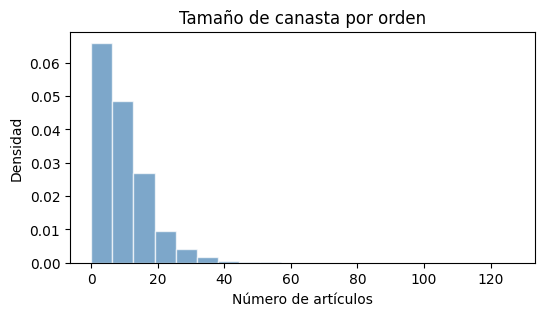

In [146]:
plt.figure(figsize=(6, 3))
plt.hist(canasta, bins=20, density=True, color='steelblue', edgecolor='white', alpha=0.7)
plt.title('Tamaño de canasta por orden')
plt.xlabel('Número de artículos')
plt.ylabel('Densidad')

plt.show()

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

In [148]:
primeros = (full_detalle_ordenes[full_detalle_ordenes['add_to_cart_order'] == 1]
            .groupby(['product_id', 'product_name'])
            .size()
            .reset_index(name='veces_primero')
            .sort_values('veces_primero', ascending=False)
            .head(20))
primeros

,product_id,product_name,veces_primero
13414,24852.0,banana,15562
7127,13176.0,bag of organic bananas,11026
15028,27845.0,organic whole milk,4363
11384,21137.0,organic strawberries,3946
25439,47209.0,organic hass avocado,3390
11786,21903.0,organic baby spinach,3336
25732,47766.0,organic avocado,3044
10622,19660.0,spring water,2336
9050,16797.0,strawberries,2308
15102,27966.0,organic raspberries,2024


In [150]:
recompra_global = (full_detalle_ordenes
                   .groupby('product_id')['reordered']
                   .mean()
                   .reset_index(name='ratio_recompra')
)
recompra_global

,product_id,ratio_recompra
0,1.0,0.564286
1,2.0,0.000000
2,3.0,0.738095
3,4.0,0.510204
4,7.0,0.500000
...,...,...
45568,49690.0,0.800000
45569,49691.0,0.430556
45570,49692.0,0.416667
45571,49693.0,0.440000


In [152]:
top20_primeros = primeros.merge(recompra_global, on='product_id')
top20_primeros

,product_id,product_name,veces_primero,ratio_recompra
0,24852.0,banana,15562,0.844254
1,13176.0,bag of organic bananas,11026,0.834006
2,27845.0,organic whole milk,4363,0.829133
3,21137.0,organic strawberries,3946,0.773212
4,47209.0,organic hass avocado,3390,0.793639
5,21903.0,organic baby spinach,3336,0.772217
6,47766.0,organic avocado,3044,0.759164
7,19660.0,spring water,2336,0.810814
8,16797.0,strawberries,2308,0.696623
9,27966.0,organic raspberries,2024,0.768245


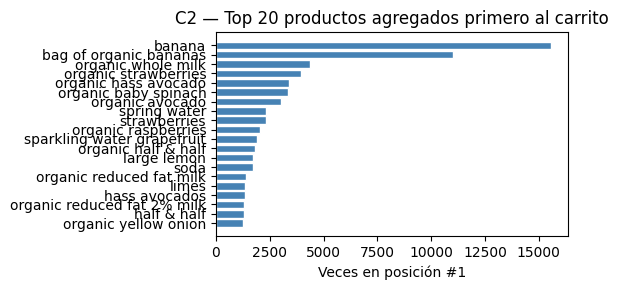

In [154]:
plt.figure(figsize=(6, 3))
plt.barh(top20_primeros['product_name'][::-1],
         top20_primeros['veces_primero'][::-1],
         color='steelblue', edgecolor='white')
plt.title('C2 — Top 20 productos agregados primero al carrito')
plt.xlabel('Veces en posición #1')
plt.tight_layout()
plt.show()

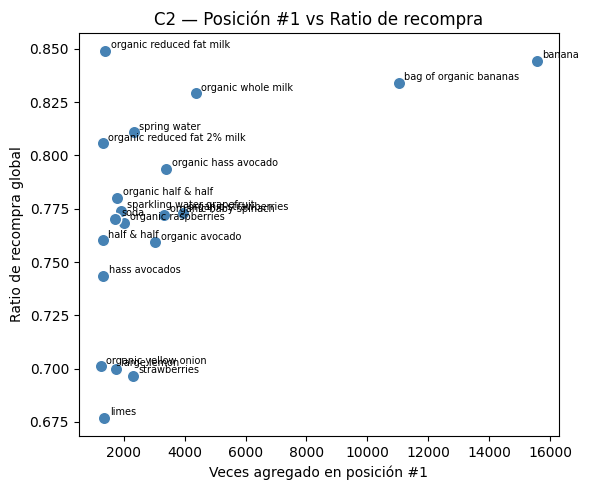

In [156]:
plt.figure(figsize=(6, 5))
plt.scatter(top20_primeros['veces_primero'], top20_primeros['ratio_recompra'],
            color='steelblue', edgecolor='white', s=80)

for _, row in top20_primeros.iterrows():
    plt.annotate(row['product_name'],
                 xy=(row['veces_primero'], row['ratio_recompra']),
                 fontsize=7, xytext=(4, 2), textcoords='offset points')

plt.title('C2 — Posición #1 vs Ratio de recompra')
plt.xlabel('Veces agregado en posición #1')
plt.ylabel('Ratio de recompra global')
plt.tight_layout()
plt.show()

In [158]:
from scipy import stats

pearson  = stats.pearsonr(top20_primeros['veces_primero'], top20_primeros['ratio_recompra'])
spearman = stats.spearmanr(top20_primeros['veces_primero'], top20_primeros['ratio_recompra'])

print(f"\nPearson  r = {pearson[0]:.3f}  | p-value = {pearson[1]:.3f}")
print(f"Spearman r = {spearman[0]:.3f}  | p-value = {spearman[1]:.3f}")


Pearson  r = 0.516  | p-value = 0.020
Spearman r = 0.481  | p-value = 0.032


**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [160]:
recompra_producto = (full_detalle_ordenes
                     .groupby(['product_id', 'product_name'])['reordered']
                     .mean()
                     .reset_index(name='ratio_recompra')
                     .sort_values('ratio_recompra', ascending=False)
)
recompra_producto.head()

,product_id,product_name,ratio_recompra
28108,30644.0,organic french roast,1.0
7340,8054.0,bissli smokey wheat snacks,1.0
28114,30650.0,mushroom lover's veggie burgers,1.0
41002,44747.0,frozen organic blackberries,1.0
40998,44743.0,real zero cola,1.0


**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

In [161]:
recompra_usuario = (full_detalle_ordenes
                    .groupby('user_id')['reordered']
                    .mean()
                    .reset_index(name='ratio_recompra')
                    .sort_values('ratio_recompra', ascending=False)
)

print(f"Total usuarios: {len(recompra_usuario):,}")
print(f"Media:   {recompra_usuario['ratio_recompra'].mean():.3f}")
print(f"Mediana: {recompra_usuario['ratio_recompra'].median():.3f}")
print(f"Skewness: {recompra_usuario['ratio_recompra'].skew():.3f}")


Total usuarios: 157,437
Media:   0.495
Mediana: 0.500
Skewness: -0.148


**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

In [164]:
orden_promedio = (full_detalle_ordenes
                  .groupby(['product_id', 'product_name'])
                  .agg(
                      posicion_promedio = ('add_to_cart_order', 'mean'),
                      total_pedidos     = ('order_id', 'count')
                  )
                  .reset_index()
                  .query('total_pedidos >= 100')  # filtro mínimo para evitar productos con 1 sola orden
                  .sort_values('posicion_promedio')
                  .head(20)
)
orden_promedio

,product_id,product_name,posicion_promedio,total_pedidos
32524,35470.0,water mineral,2.637462,331
24680,26900.0,usda aa extra large eggs,2.822981,322
19187,20940.0,organic low fat milk,2.843271,1174
20902,22802.0,mineral water,2.906542,856
16408,17924.0,seltzer water,3.052632,247
10838,11885.0,sparkling water- bottles,3.141463,205
29030,31651.0,extra fancy unsalted mixed nuts,3.173398,1436
24227,26405.0,xl pick-a-size paper towel rolls,3.173913,161
42302,46149.0,zero calorie cola,3.228503,1256
37517,40939.0,drinking water,3.252264,773


### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

* La canasta promedio es de 10 artículos con distribución leptocúrtica (kurtosis = 4.13) y cola derecha (skewness = 1.56), concentrándose la mayoría entre 5 y 14 artículos.
* Existe una correlación moderada-positiva significativa entre ser agregado primero al carrito y tener alto ratio de recompra (Pearson r = 0.516, p = 0.020), siendo banana y bag of organic bananas los productos más priorizados.
* Varios productos presentan ratio de recompra = 1.0, identificándolos como productos de consumo absolutamente habitual para sus compradores.
* Los usuarios dividen casi equitativamente sus compras entre productos nuevos y conocidos (media = 0.495, mediana = 0.500), sin tendencia dominante hacia exploración ni hábito.
* Los productos priorizados al inicio del carrito son esenciales del hogar — agua, huevos y leche — con posición promedio entre 2.6 y 3.4, revelando una lista mental de compras básicas.

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.

El dataset presentó valores ausentes en variables clave, duplicados, no se analizaron outliers en todas las tablas, sin embargo, en la columna analizada, no se encontraron outliers. La demanda se concentra domingos y lunes entre 10h–15h; existen dos tipos de cliente, los que compran cada semana y lo que compran cada mes; y los productos orgánicos frescos, liderados por banana, son las anclas del carrito con los ratios de recompra más altos del catálogo.